# ML usage in earthquake detection/classification.
## Babcsán Gergely , Hiri Olivér


Important libraries for machine learning models:\
We used scikit-learn (sklearn) for building the machine learning models,\
 pandas for reading the data, and matplotlib for data visualization.

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler


## Loading earthquake data. 

MSE: 95796.958
R² score: 0.181


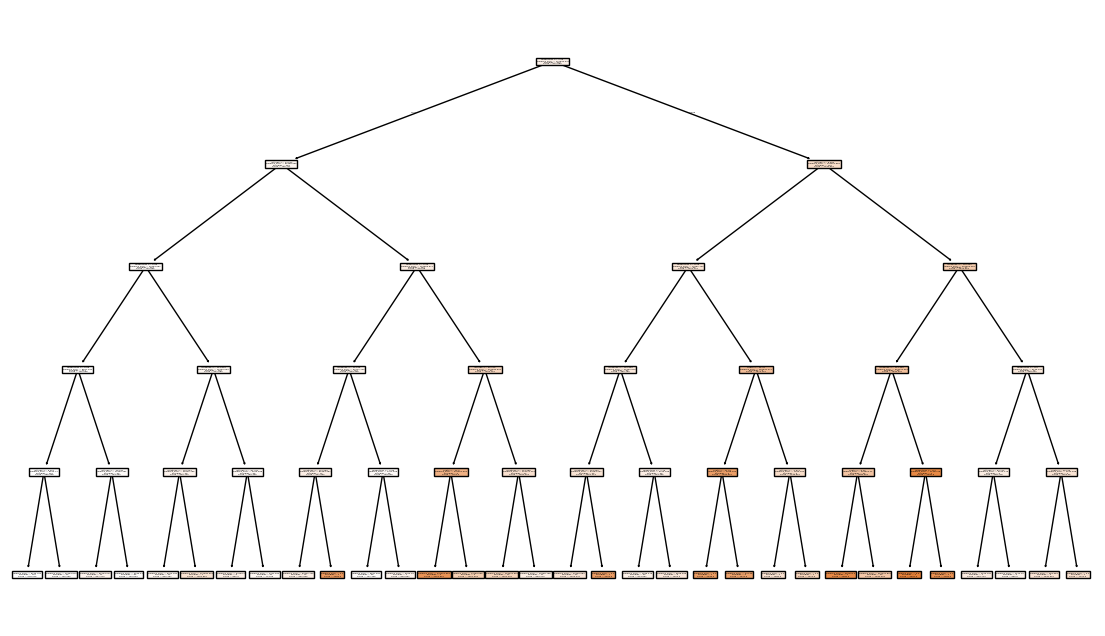

In [ ]:
# Load data
df = pd.read_csv("earthquake_data.csv", on_bad_lines="skip")

# Drop non-numeric / problematic columns
df = df.drop(columns=[
    'title',  'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
        'net', 'nst', 'dmin', 'gap', 'magType',  
        'location', 'continent', 'country'
])

# ── Define features and target ────────────────────────────────────────────
# Remove missing values
df = df.dropna()
TARGET   = "sig"
FEATURES = [col for col in df.columns if col != TARGET]

# Target
y = df[TARGET]

# Features
X = df[FEATURES]
feature_names = X.columns.astype(str)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## Simple decision tree

MSE: 0.886
R² score: 0.213


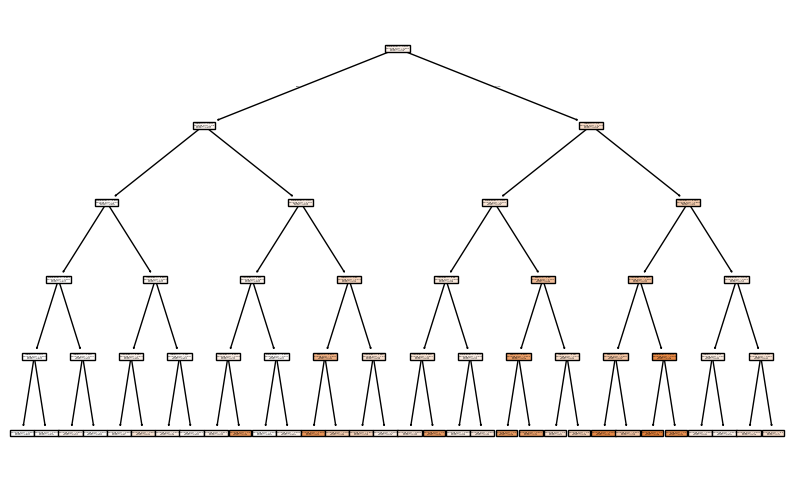

In [7]:
reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test) # Predict 

mse = mean_squared_error(y_test, y_pred) # Evaluate
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.3f}")
print(f"R² score: {r2:.3f}")

plt.figure(figsize=(10, 6)) # Plot tree
plot_tree(reg, feature_names=feature_names, filled=True)
plt.show()

## Random forest model

Best max_depth: 18  →  Test R² = 0.415


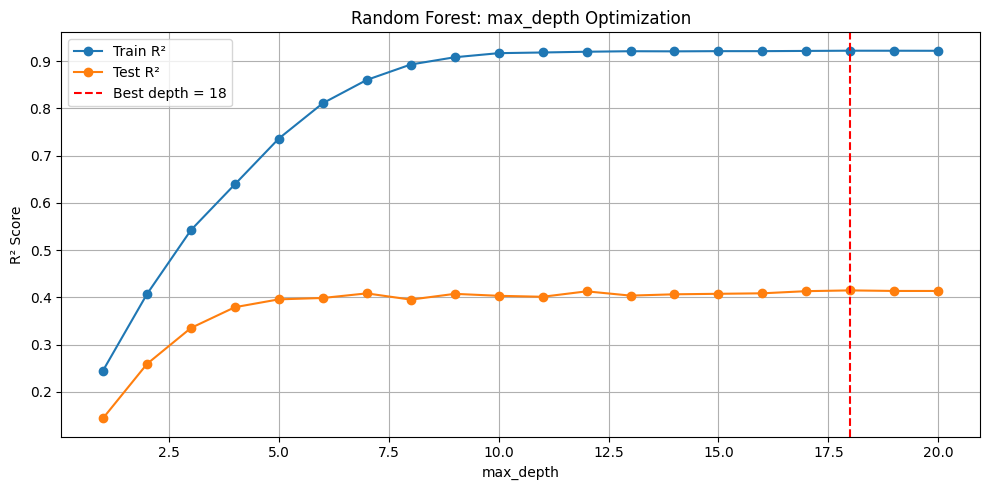

MSE: 70671.826
R² score: 0.415


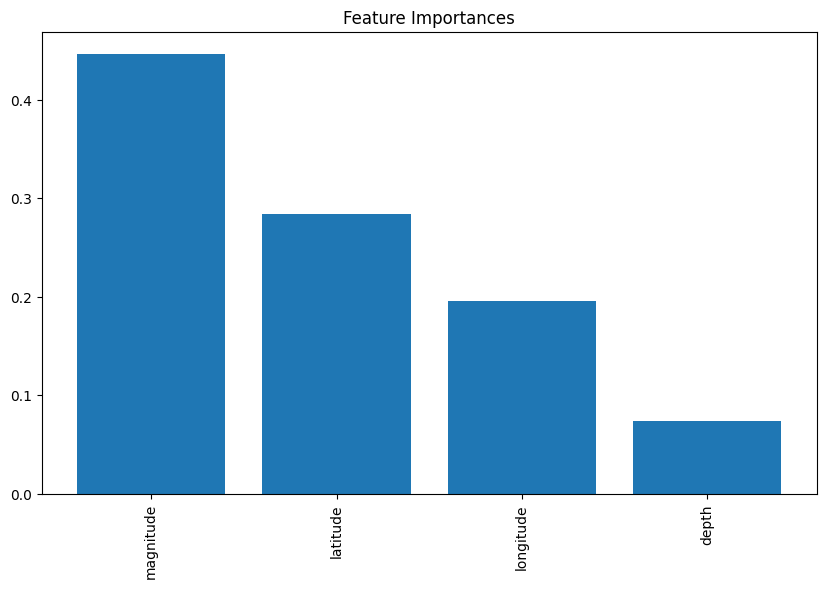

In [4]:
#Random Forest─────────────────────────────────────────────────────────


depths = range(1, 21)
train_r2 = []
test_r2  = []

for depth in depths:
    rf = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, rf.predict(X_train)))
    test_r2.append(r2_score(y_test,  rf.predict(X_test)))

# Find best depth

best_depth = depths[np.argmax(test_r2)]
best_r2    = max(test_r2)
print(f"Best max_depth: {best_depth}  →  Test R² = {best_r2:.3f}")

# Plot

plt.figure(figsize=(10, 5))
plt.plot(depths, train_r2, label="Train R²", marker="o")
plt.plot(depths, test_r2,  label="Test R²",  marker="o")
plt.axvline(best_depth, color="red", linestyle="--", label=f"Best depth = {best_depth}")
plt.xlabel("max_depth")
plt.ylabel("R² Score")
plt.title("Random Forest: max_depth Optimization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Retrain with best depth 

rf_best = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_best.fit(X_train, y_train)
y_pred = rf_best.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.3f}")
print(f"R² score: {best_r2:.3f}")

#plotting the feature importance
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.show()


## Linear regression


  Linear Regression Results (sig prediction)
  MAE  : 158.12
  MSE  : 85114.28
  RMSE : 291.74
  R²   : 0.2725

  5-fold CV R² : 0.2189 ± 0.2907

Feature coefficients (sorted by absolute value):
  feature  coefficient
magnitude   165.828565
 latitude    68.479106
longitude   -57.855672
    depth   -28.685759

Intercept: 867.52


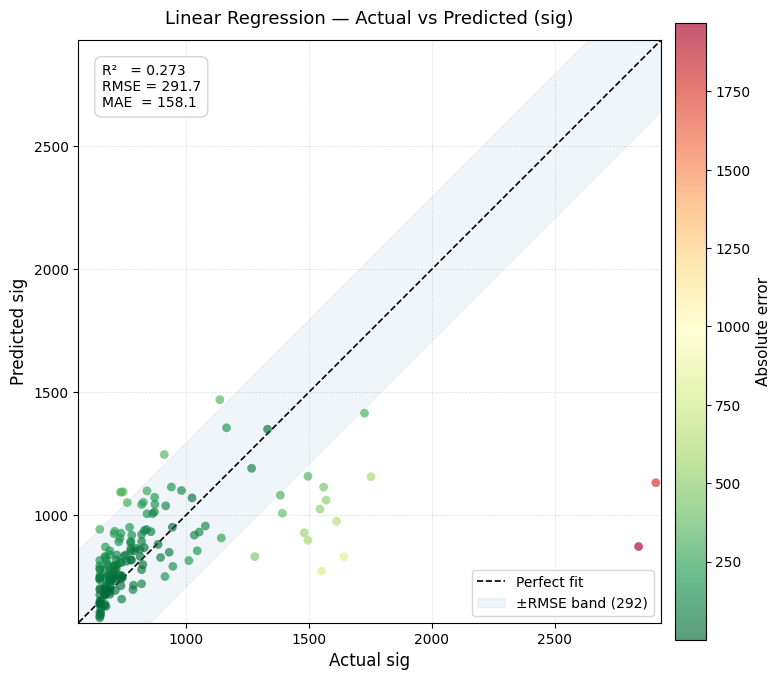

In [5]:
#Linear Regression─────────────────────────────────────────────────────────
 
#  Scale features 
# Linear regression isn't sensitive to scale for coefficient estimation,
# but scaling makes coefficients comparable and improves numerical stability.
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()
#Train / test split 
 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
 
#Fit model
 
model = LinearRegression()
model.fit(X_train, y_train)
 
# Evaluate 
 
y_pred = model.predict(X_test)
 
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
 
print("=" * 50)
print("  Linear Regression Results (sig prediction)")
print("=" * 50)
print(f"  MAE  : {mae:.2f}")
print(f"  MSE  : {mse:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}")
print("=" * 50)
 
# 5-fold cross-validation
cv_r2 = cross_val_score(model, X_scaled, y, cv=5, scoring="r2")
print(f"\n  5-fold CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}\n")
 
# Feature coefficients 
# Scaled coefficients show the relative importance of each feature.
 
coef_df = pd.DataFrame({
    "feature"    : FEATURES,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)
 
print("Feature coefficients (sorted by absolute value):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.2f}")
 

fig, ax = plt.subplots(figsize=(8, 7))
 
# colour-code by residual magnitude 
residuals     = y_test - y_pred
abs_residuals = np.abs(residuals)
norm          = plt.Normalize(abs_residuals.min(), abs_residuals.max())
colours       = plt.cm.RdYlGn_r(norm(abs_residuals))  # green=small error, red=large
 
scatter = ax.scatter(
    y_test, y_pred,
    c=abs_residuals, cmap="RdYlGn_r",
    alpha=0.65, edgecolors="none", s=40, zorder=3
)
 
# perfect-fit diagonal 
lims = [min(y_test.min(), y_pred.min()) - 20,
        max(y_test.max(), y_pred.max()) + 20]
ax.plot(lims, lims, "k--", linewidth=1.2, label="Perfect fit", zorder=2)
 
# ±RMSE band around the diagonal
ax.fill_between(lims,
                [l - rmse for l in lims],
                [l + rmse for l in lims],
                alpha=0.08, color="steelblue", label=f"±RMSE band ({rmse:.0f})")
 
# colour bar 
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Absolute error", fontsize=11)
 
# metric annotation box 
stats_text = (
    f"R²   = {r2:.3f}\n"
    f"RMSE = {rmse:.1f}\n"
    f"MAE  = {mae:.1f}"
)
ax.text(
    0.04, 0.96, stats_text,
    transform=ax.transAxes,
    fontsize=10, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
              edgecolor="#cccccc", alpha=0.85)
)
 
# --- labels ---
ax.set_xlabel("Actual sig", fontsize=12)
ax.set_ylabel("Predicted sig", fontsize=12)
ax.set_title("Linear Regression — Actual vs Predicted (sig)", fontsize=13, pad=12)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
 
plt.tight_layout()
plt.show()



## Support Vector Regression

In [6]:
#SVR─────────────────────────────────────────────────────────
#  Train / test split 

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Grid search for best C & epsilon 

print("Running GridSearchCV (RBF kernel) …")
param_grid = {
    "C":       [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "gamma":   ["scale", "auto"],
}
grid = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
grid.fit(X_train, y_train)
best_params = grid.best_params_
print(f"Best params: {best_params}")
print(f"Best CV R²:  {grid.best_score_:.4f}\n")

# Final model

model = grid.best_estimator_

y_pred_scaled = model.predict(X_test)

# Inverse-transform back to original sig scale
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("=" * 50)
print("  SVR Regression Results (sig prediction)")
print("=" * 50)
print(f"  MAE  : {mae:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}")
print("=" * 50)

# 5-fold CV on full data
cv_r2 = cross_val_score(model, X_scaled, y_scaled, cv=5, scoring="r2")
print(f"\n  5-fold CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

Running GridSearchCV (RBF kernel) …
Best params: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto'}
Best CV R²:  0.4309

  SVR Regression Results (sig prediction)
  MAE  : 120.33
  RMSE : 279.57
  R²   : 0.3319

  5-fold CV R² : 0.3268 ± 0.1461
